In [1]:
# ================================================
# PRISONER'S DILEMMA IN FINANCIAL MARKETS
# Game Theory + Finance Simulation Project
# ================================================

"""
Project Title: Prisoner's Dilemma in Financial Markets
Author: [Your Name]
Date: April 2026

What is the Prisoner's Dilemma?
- A classic game theory scenario where two players can either Cooperate or Defect.
- Individually rational choice (Defect) leads to worse collective outcome.

Why it matters in Finance & Economics:
- Explains price wars, collusion, excessive risk-taking, and lack of trust in markets.
- Shows how repeated interactions (long-term relationships) can encourage cooperation.

In this project:
- Cooperate = Maintain healthy market behavior (fair pricing, prudent risk, information sharing)
- Defect    = Act aggressively for short-term gain (predatory pricing, excessive risk, withholding info)

What the simulation demonstrates:
- One-shot games often lead to mutual defection (bad for market).
- Repeated games + smart strategies can sustain cooperation.
- Real financial insights through visualizations and analysis.
"""

# ------------------- Imports -------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import itertools
from typing import Callable, Tuple, List, Dict

# Set style for professional-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("✅ Setup complete! All libraries imported successfully.")

✅ Setup complete! All libraries imported successfully.


In [2]:
# ------------------- Payoff Matrix -------------------
# Standard Prisoner's Dilemma payoffs
# R > P, T > R, S < P, and 2*R > T + S (ensures mutual cooperation is best overall)

REWARD = 3        # Both cooperate → healthy market, steady profits
TEMPTATION = 5    # Defect while other cooperates → short-term gain (steal market share)
SUCKER = 0        # Cooperate while other defects → lose out badly
PUNISHMENT = 1    # Both defect → aggressive competition hurts everyone (price war, higher risk)

payoff_matrix = {
    ('C', 'C'): (REWARD, REWARD),
    ('C', 'D'): (SUCKER, TEMPTATION),
    ('D', 'C'): (TEMPTATION, SUCKER),
    ('D', 'D'): (PUNISHMENT, PUNISHMENT)
}

def get_payoff(action_a: str, action_b: str) -> Tuple[int, int]:
    """Return payoffs for Player A and Player B given their actions."""
    return payoff_matrix[(action_a, action_b)]

print("✅ Payoff Matrix Defined (Financial Interpretation):")
print("• (C, C) → Both firms behave responsibly → Stable profits (3, 3)")
print("• (D, C) → Aggressive firm exploits fair firm → Big short-term gain (5, 0)")
print("• (C, D) → Fair firm loses to aggressive competitor (0, 5)")
print("• (D, D) → Price war / risk arms race → Low profits for both (1, 1)")

# Verify it's a valid Prisoner's Dilemma
print("\n✅ PD Conditions Check:")
print(f"Temptation > Reward > Punishment > Sucker : {TEMPTATION > REWARD > PUNISHMENT > SUCKER}")
print(f"2×Reward > Temptation + Sucker           : {2*REWARD > TEMPTATION + SUCKER}")

✅ Payoff Matrix Defined (Financial Interpretation):
• (C, C) → Both firms behave responsibly → Stable profits (3, 3)
• (D, C) → Aggressive firm exploits fair firm → Big short-term gain (5, 0)
• (C, D) → Fair firm loses to aggressive competitor (0, 5)
• (D, D) → Price war / risk arms race → Low profits for both (1, 1)

✅ PD Conditions Check:
Temptation > Reward > Punishment > Sucker : True
2×Reward > Temptation + Sucker           : True


In [3]:
# ------------------- One-Shot Game -------------------
print("=== One-Shot Prisoner's Dilemma Simulation ===\n")

# Interactive inputs (change these values and re-run the cell)
player_a_action = 'C'   # Change to 'C' or 'D'
player_b_action = 'D'   # Change to 'C' or 'D'

pay_a, pay_b = get_payoff(player_a_action, player_b_action)

print(f"Player A (Firm 1) chooses: {'Cooperate' if player_a_action=='C' else 'Defect'}")
print(f"Player B (Firm 2) chooses: {'Cooperate' if player_b_action=='C' else 'Defect'}")
print(f"Payoff → Firm 1: {pay_a} | Firm 2: {pay_b}\n")

# Full outcome table
print("All Possible Outcomes:")
data = []
for a in ['C', 'D']:
    for b in ['C', 'D']:
        pa, pb = get_payoff(a, b)
        outcome = f"({a},{b})"
        interpretation = {
            ('C','C'): "Both firms cooperate → Healthy market",
            ('C','D'): "Firm 1 is exploited",
            ('D','C'): "Firm 2 is exploited",
            ('D','D'): "Mutual aggression → Price war hurts both"
        }[(a,b)]
        data.append([outcome, pa, pb, interpretation])

df_one_shot = pd.DataFrame(data, columns=["Actions (A,B)", "Payoff A", "Payoff B", "Financial Meaning"])
display(df_one_shot)

=== One-Shot Prisoner's Dilemma Simulation ===

Player A (Firm 1) chooses: Cooperate
Player B (Firm 2) chooses: Defect
Payoff → Firm 1: 0 | Firm 2: 5

All Possible Outcomes:


,"Actions (A,B)",Payoff A,Payoff B,Financial Meaning
0,"(C,C)",3,3,Both firms cooperate → Healthy market
1,"(C,D)",0,5,Firm 1 is exploited
2,"(D,C)",5,0,Firm 2 is exploited
3,"(D,D)",1,1,Mutual aggression → Price war hurts both


In [4]:
# ================================================
# SECTION 4: Repeated Prisoner's Dilemma
# ================================================

def simulate_repeated_game(strategy_a: Callable, strategy_b: Callable,
                          num_rounds: int = 100,
                          seed: int = RANDOM_SEED) -> pd.DataFrame:
    """
    Simulate a repeated Prisoner's Dilemma game between two strategies.

    Args:
        strategy_a, strategy_b: Functions that take (history_a, history_b, round_num) and return 'C' or 'D'
        num_rounds: Number of rounds to play
        seed: Random seed for reproducibility

    Returns:
        pandas DataFrame with round-by-round results
    """
    random.seed(seed)
    np.random.seed(seed)

    history_a: List[str] = []   # Actions of Player A so far
    history_b: List[str] = []   # Actions of Player B so far

    results = []
    cumulative_a = 0
    cumulative_b = 0

    for round_num in range(1, num_rounds + 1):
        # Get actions from strategies (pass history and current round)
        action_a = strategy_a(history_a, history_b, round_num)
        action_b = strategy_b(history_b, history_a, round_num)  # Note: history swapped for B

        # Get payoffs
        payoff_a, payoff_b = get_payoff(action_a, action_b)

        # Update cumulatives
        cumulative_a += payoff_a
        cumulative_b += payoff_b

        # Record round
        results.append({
            'Round': round_num,
            'Player_A_Action': action_a,
            'Player_B_Action': action_b,
            'Payoff_A': payoff_a,
            'Payoff_B': payoff_b,
            'Cumulative_A': cumulative_a,
            'Cumulative_B': cumulative_b
        })

        # Update histories
        history_a.append(action_a)
        history_b.append(action_b)

    df = pd.DataFrame(results)
    return df


# Simple test of repeated game (using always cooperate for both)
def always_cooperate(history_a, history_b, round_num):
    return 'C'

print("✅ Repeated game simulation function defined.")
print("Test run with 10 rounds (Both Always Cooperate):")

test_df = simulate_repeated_game(always_cooperate, always_cooperate, num_rounds=10)
display(test_df.head(10))
print(f"\nFinal Cumulative Payoffs → A: {test_df['Cumulative_A'].iloc[-1]}, B: {test_df['Cumulative_B'].iloc[-1]}")

✅ Repeated game simulation function defined.
Test run with 10 rounds (Both Always Cooperate):


,Round,Player_A_Action,Player_B_Action,Payoff_A,Payoff_B,Cumulative_A,Cumulative_B
0,1,C,C,3,3,3,3
1,2,C,C,3,3,6,6
2,3,C,C,3,3,9,9
3,4,C,C,3,3,12,12
4,5,C,C,3,3,15,15
5,6,C,C,3,3,18,18
6,7,C,C,3,3,21,21
7,8,C,C,3,3,24,24
8,9,C,C,3,3,27,27
9,10,C,C,3,3,30,30



Final Cumulative Payoffs → A: 30, B: 30


In [5]:
# ================================================
# SECTION 5: Strategy Framework
# ================================================

# ------------------- Strategy Definitions -------------------

def always_cooperate(history_a: List[str], history_b: List[str], round_num: int) -> str:
    """Always Cooperate: Never defects. Represents a firm committed to ethical, long-term behavior."""
    return 'C'

def always_defect(history_a: List[str], history_b: List[str], round_num: int) -> str:
    """Always Defect: Always chooses aggressive behavior. Represents a firm that exploits every opportunity."""
    return 'D'

def random_strategy(history_a: List[str], history_b: List[str], round_num: int) -> str:
    """Random: Chooses Cooperate or Defect with 50% probability each round. Models unpredictable market behavior."""
    return random.choice(['C', 'D'])

def tit_for_tat(history_a: List[str], history_b: List[str], round_num: int) -> str:
    """
    Tit for Tat: Start with Cooperate, then copy opponent's previous move.
    Famous strategy: Nice, retaliatory, forgiving, and clear.
    Very successful in repeated games.
    """
    if not history_b:  # First round
        return 'C'
    return history_b[-1]  # Copy opponent's last action

def grudger(history_a: List[str], history_b: List[str], round_num: int) -> str:
    """
    Grudger (Grim Trigger): Cooperate until opponent defects once, then defect forever.
    Represents "once burned, twice shy" — common in business relationships after betrayal.
    """
    if not history_b:
        return 'C'
    if 'D' in history_b:  # If opponent ever defected
        return 'D'
    return 'C'

def pavlov(history_a: List[str], history_b: List[str], round_num: int) -> str:
    """
    Pavlov (Win-Stay, Lose-Shift):
    - If you won or tied last round (got Reward or Temptation), repeat your action.
    - If you lost (got Sucker or Punishment), switch your action.
    Simple reinforcement learning style strategy.
    """
    if not history_a:  # First round
        return 'C'

    my_last_action = history_a[-1]
    my_last_payoff = get_payoff(my_last_action, history_b[-1])[0]  # Payoff for Player A perspective

    if my_last_payoff >= REWARD:  # Won or tied (3 or 5)
        return my_last_action
    else:  # Lost (0 or 1)
        return 'D' if my_last_action == 'C' else 'C'


# Dictionary of all strategies for easy access
STRATEGIES = {
    'Always Cooperate': always_cooperate,
    'Always Defect': always_defect,
    'Random': random_strategy,
    'Tit for Tat': tit_for_tat,
    'Grudger': grudger,
    'Pavlov': pavlov
}

print("✅ All 6 strategies defined successfully!")
print("Available strategies:", list(STRATEGIES.keys()))

# Quick demonstration: Tit for Tat vs Always Defect (10 rounds)
print("\nDemonstration: Tit for Tat vs Always Defect (10 rounds)")
demo_df = simulate_repeated_game(tit_for_tat, always_defect, num_rounds=10)
display(demo_df)

✅ All 6 strategies defined successfully!
Available strategies: ['Always Cooperate', 'Always Defect', 'Random', 'Tit for Tat', 'Grudger', 'Pavlov']

Demonstration: Tit for Tat vs Always Defect (10 rounds)


,Round,Player_A_Action,Player_B_Action,Payoff_A,Payoff_B,Cumulative_A,Cumulative_B
0,1,C,D,0,5,0,5
1,2,D,D,1,1,1,6
2,3,D,D,1,1,2,7
3,4,D,D,1,1,3,8
4,5,D,D,1,1,4,9
5,6,D,D,1,1,5,10
6,7,D,D,1,1,6,11
7,8,D,D,1,1,7,12
8,9,D,D,1,1,8,13
9,10,D,D,1,1,9,14


In [6]:
# ================================================
# SECTION 6: Head-to-Head Match Engine
# ================================================

def run_head_to_head(strategy_a_name: str, strategy_b_name: str,
                    num_rounds: int = 100,
                    seed: int = RANDOM_SEED) -> pd.DataFrame:
    """
    Run a repeated Prisoner's Dilemma match between any two strategies.

    Args:
        strategy_a_name: Name of strategy for Player A (from STRATEGIES dict)
        strategy_b_name: Name of strategy for Player B
        num_rounds: Number of rounds
        seed: Random seed for reproducibility

    Returns:
        DataFrame with full round-by-round results + summary statistics
    """
    strategy_a = STRATEGIES[strategy_a_name]
    strategy_b = STRATEGIES[strategy_b_name]

    # Run the simulation
    df = simulate_repeated_game(strategy_a, strategy_b, num_rounds, seed)

    # Calculate summary statistics
    total_a = df['Cumulative_A'].iloc[-1]
    total_b = df['Cumulative_B'].iloc[-1]
    avg_a = total_a / num_rounds
    avg_b = total_b / num_rounds

    coop_rate_a = (df['Player_A_Action'] == 'C').mean() * 100
    coop_rate_b = (df['Player_B_Action'] == 'C').mean() * 100
    defect_rate_a = 100 - coop_rate_a
    defect_rate_b = 100 - coop_rate_b

    print(f"\n=== Head-to-Head: {strategy_a_name} vs {strategy_b_name} ===")
    print(f"Rounds played: {num_rounds}")
    print(f"Total Payoff → {strategy_a_name}: {total_a:.1f} | {strategy_b_name}: {total_b:.1f}")
    print(f"Average Payoff per round → {strategy_a_name}: {avg_a:.2f} | {strategy_b_name}: {avg_b:.2f}")
    print(f"Cooperation Rate → {strategy_a_name}: {coop_rate_a:.1f}% | {strategy_b_name}: {coop_rate_b:.1f}%")

    # Add summary as attributes to the DataFrame for easy access later
    df.attrs['strategy_a'] = strategy_a_name
    df.attrs['strategy_b'] = strategy_b_name
    df.attrs['total_a'] = total_a
    df.attrs['total_b'] = total_b
    df.attrs['avg_a'] = avg_a
    df.attrs['avg_b'] = avg_b
    df.attrs['coop_rate_a'] = coop_rate_a
    df.attrs['coop_rate_b'] = coop_rate_b

    return df


# ------------------- Test the Match Engine -------------------
print("Testing Head-to-Head Match Engine...\n")

# Example 1: Tit for Tat vs Always Defect
df_tft_vs_ad = run_head_to_head('Tit for Tat', 'Always Defect', num_rounds=50)
display(df_tft_vs_ad.tail(5))  # Show last few rounds

# Example 2: Pavlov vs Grudger
print("\n" + "="*60)
df_pavlov_vs_grudger = run_head_to_head('Pavlov', 'Grudger', num_rounds=30)

Testing Head-to-Head Match Engine...


=== Head-to-Head: Tit for Tat vs Always Defect ===
Rounds played: 50
Total Payoff → Tit for Tat: 49.0 | Always Defect: 54.0
Average Payoff per round → Tit for Tat: 0.98 | Always Defect: 1.08
Cooperation Rate → Tit for Tat: 2.0% | Always Defect: 0.0%


,Round,Player_A_Action,Player_B_Action,Payoff_A,Payoff_B,Cumulative_A,Cumulative_B
45,46,D,D,1,1,45,50
46,47,D,D,1,1,46,51
47,48,D,D,1,1,47,52
48,49,D,D,1,1,48,53
49,50,D,D,1,1,49,54




=== Head-to-Head: Pavlov vs Grudger ===
Rounds played: 30
Total Payoff → Pavlov: 90.0 | Grudger: 90.0
Average Payoff per round → Pavlov: 3.00 | Grudger: 3.00
Cooperation Rate → Pavlov: 100.0% | Grudger: 100.0%


In [7]:
# ================================================
# SECTION 7: Tournament System + Leaderboard
# ================================================

def run_tournament(num_rounds: int = 100,
                  num_repeats: int = 3,
                  seeds: List[int] = None) -> pd.DataFrame:
    """
    Run a round-robin tournament where every strategy plays against every other strategy.

    Args:
        num_rounds: Rounds per match
        num_repeats: How many times to repeat each pair (for averaging)
        seeds: Optional list of seeds for different runs

    Returns:
        DataFrame with tournament results + aggregated leaderboard
    """
    if seeds is None:
        seeds = [RANDOM_SEED + i for i in range(num_repeats)]

    strategies_list = list(STRATEGIES.keys())
    results = []

    print(f"Running Tournament: {len(strategies_list)} strategies × {num_rounds} rounds × {num_repeats} repeats")
    print("This may take a few seconds...\n")

    total_matches = len(strategies_list) * (len(strategies_list) - 1) * num_repeats
    match_count = 0

    for strat_a_name, strat_b_name in itertools.product(strategies_list, repeat=2):
        if strat_a_name == strat_b_name:
            continue  # Skip self-matches

        for seed in seeds:
            match_count += 1
            if match_count % 20 == 0:
                print(f"Progress: {match_count}/{total_matches} matches completed")

            df_match = run_head_to_head(strat_a_name, strat_b_name, num_rounds, seed)

            results.append({
                'Strategy_A': strat_a_name,
                'Strategy_B': strat_b_name,
                'Total_Payoff_A': df_match.attrs['total_a'],
                'Total_Payoff_B': df_match.attrs['total_b'],
                'Avg_Payoff_A': df_match.attrs['avg_a'],
                'Avg_Payoff_B': df_match.attrs['avg_b'],
                'Coop_Rate_A': df_match.attrs['coop_rate_a'],
                'Coop_Rate_B': df_match.attrs['coop_rate_b'],
                'Seed': seed
            })

    # Create full tournament DataFrame
    tournament_df = pd.DataFrame(results)

    # Aggregated leaderboard by strategy
    leaderboard = []
    for strat in strategies_list:
        # When this strategy is Player A
        as_a = tournament_df[tournament_df['Strategy_A'] == strat]
        # When this strategy is Player B (swap payoffs)
        as_b = tournament_df[tournament_df['Strategy_B'] == strat].copy()
        as_b['Total_Payoff'] = as_b['Total_Payoff_B']
        as_b['Avg_Payoff'] = as_b['Avg_Payoff_B']
        as_b['Coop_Rate'] = as_b['Coop_Rate_B']

        combined = pd.concat([as_a.rename(columns={'Total_Payoff_A':'Total_Payoff',
                                                 'Avg_Payoff_A':'Avg_Payoff',
                                                 'Coop_Rate_A':'Coop_Rate'}),
                              as_b])

        avg_total = combined['Total_Payoff'].mean()
        avg_payoff = combined['Avg_Payoff'].mean()
        avg_coop = combined['Coop_Rate'].mean()

        leaderboard.append({
            'Strategy': strat,
            'Avg_Total_Payoff': round(avg_total, 1),
            'Mean_Payoff_per_Round': round(avg_payoff, 2),
            'Avg_Cooperation_Rate': round(avg_coop, 1),
            'Matches_Played': len(combined)
        })

    leaderboard_df = pd.DataFrame(leaderboard)
    leaderboard_df = leaderboard_df.sort_values('Mean_Payoff_per_Round', ascending=False).reset_index(drop=True)
    leaderboard_df['Rank'] = leaderboard_df.index + 1

    print("\n✅ Tournament completed!")
    print("Tournament Leaderboard (by Mean Payoff per Round):")
    display(leaderboard_df)

    return tournament_df, leaderboard_df


# ------------------- Run the Full Tournament -------------------
print("Starting Full Tournament...\n")

# Run with reasonable settings for Colab speed (you can increase later)
tournament_results, leaderboard = run_tournament(
    num_rounds=100,
    num_repeats=2,      # 2 repeats for balance between speed and robustness
    seeds=[42, 43]
)

# Optional: Export to CSV
tournament_results.to_csv('prisoners_dilemma_tournament_results.csv', index=False)
print("\n✅ Tournament results exported to 'prisoners_dilemma_tournament_results.csv'")

Starting Full Tournament...

Running Tournament: 6 strategies × 100 rounds × 2 repeats
This may take a few seconds...


=== Head-to-Head: Always Cooperate vs Always Defect ===
Rounds played: 100
Total Payoff → Always Cooperate: 0.0 | Always Defect: 500.0
Average Payoff per round → Always Cooperate: 0.00 | Always Defect: 5.00
Cooperation Rate → Always Cooperate: 100.0% | Always Defect: 0.0%

=== Head-to-Head: Always Cooperate vs Always Defect ===
Rounds played: 100
Total Payoff → Always Cooperate: 0.0 | Always Defect: 500.0
Average Payoff per round → Always Cooperate: 0.00 | Always Defect: 5.00
Cooperation Rate → Always Cooperate: 100.0% | Always Defect: 0.0%

=== Head-to-Head: Always Cooperate vs Random ===
Rounds played: 100
Total Payoff → Always Cooperate: 168.0 | Random: 388.0
Average Payoff per round → Always Cooperate: 1.68 | Random: 3.88
Cooperation Rate → Always Cooperate: 100.0% | Random: 56.0%

=== Head-to-Head: Always Cooperate vs Random ===
Rounds played: 100
Total Payoff → 

,Strategy,Avg_Total_Payoff,Mean_Payoff_per_Round,Avg_Cooperation_Rate,Matches_Played,Rank
0,Always Defect,265.6,2.66,0.0,20,1
1,Grudger,263.0,2.63,60.7,20,2
2,Tit for Tat,246.2,2.46,71.3,20,3
3,Pavlov,238.7,2.39,79.9,20,4
4,Always Cooperate,213.0,2.13,100.0,20,5
5,Random,187.8,1.88,55.0,20,6



✅ Tournament results exported to 'prisoners_dilemma_tournament_results.csv'


Generating Professional Visualizations...



/tmp/ipykernel_3491/4112601267.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


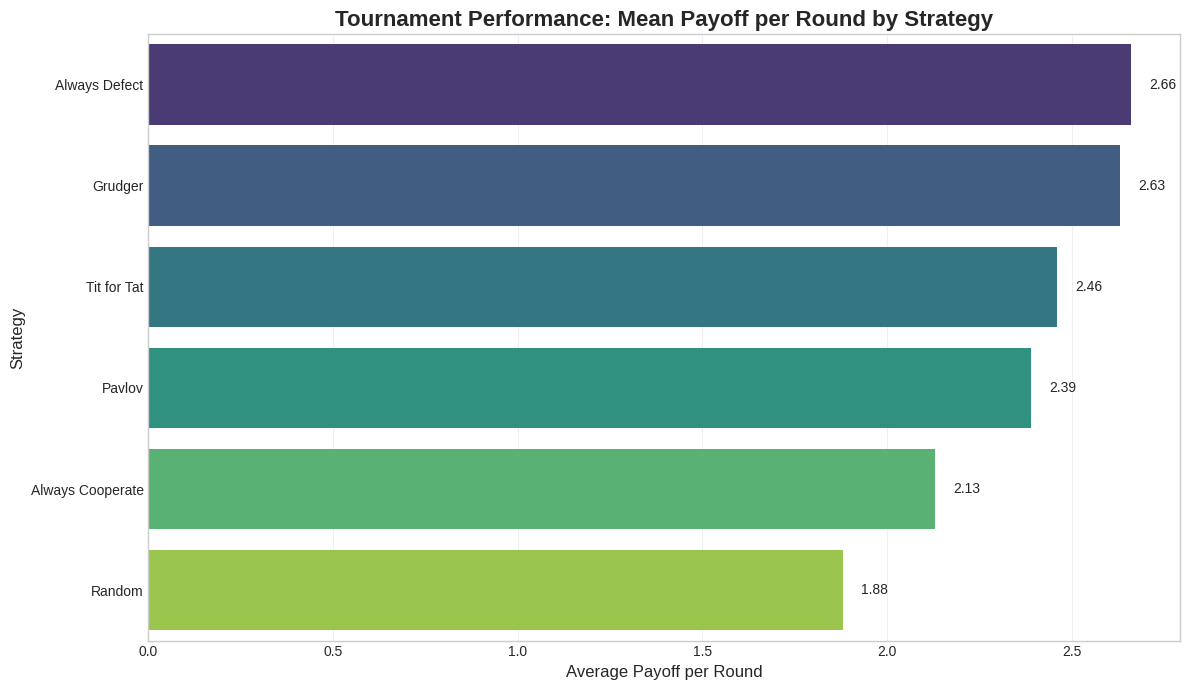

/tmp/ipykernel_3491/4112601267.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


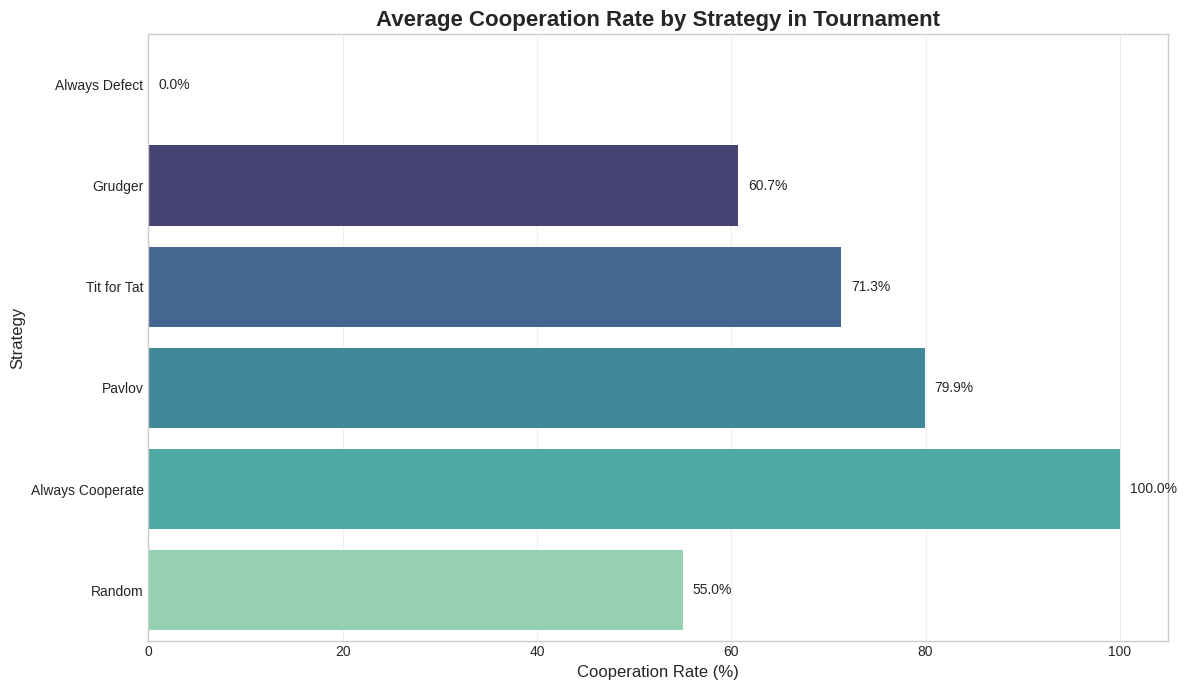

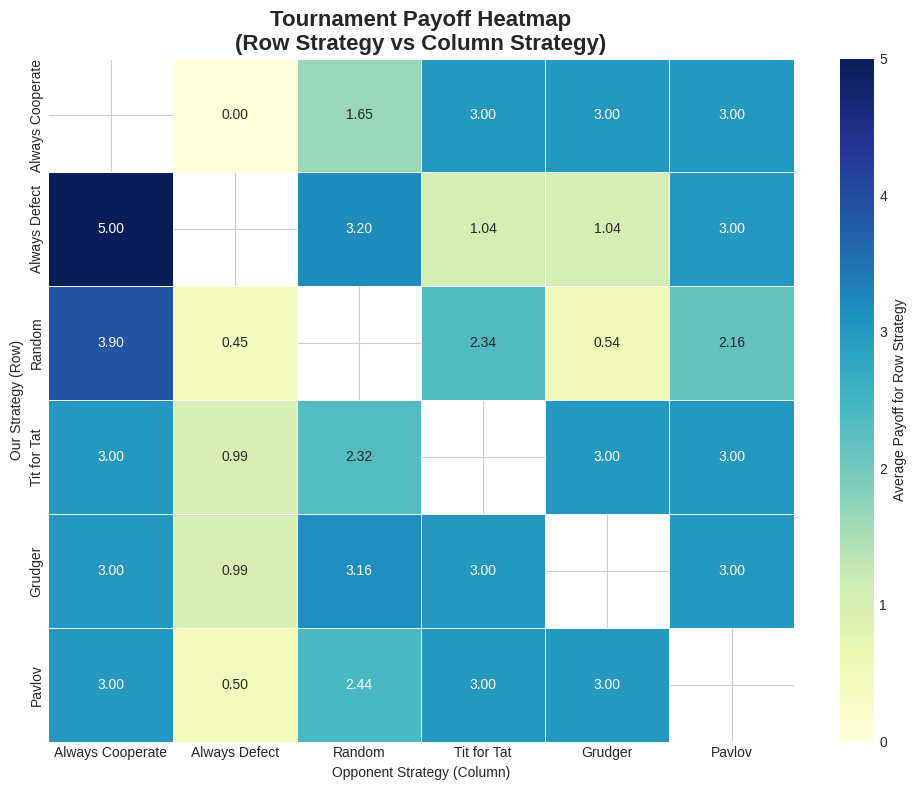


=== Head-to-Head: Tit for Tat vs Always Defect ===
Rounds played: 100
Total Payoff → Tit for Tat: 99.0 | Always Defect: 104.0
Average Payoff per round → Tit for Tat: 0.99 | Always Defect: 1.04
Cooperation Rate → Tit for Tat: 1.0% | Always Defect: 0.0%


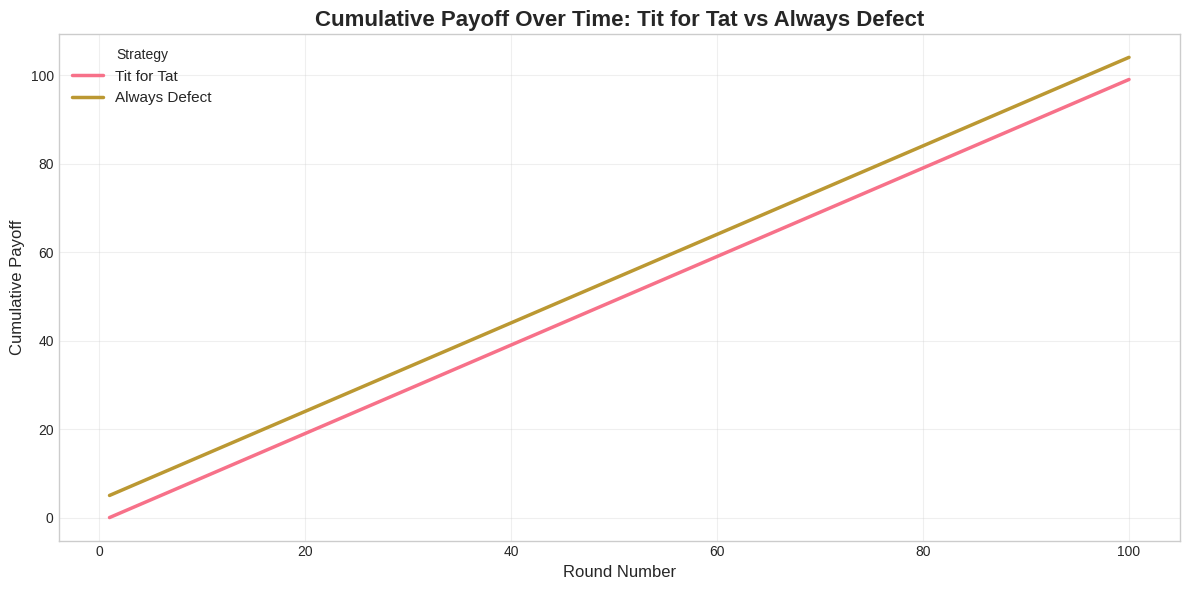

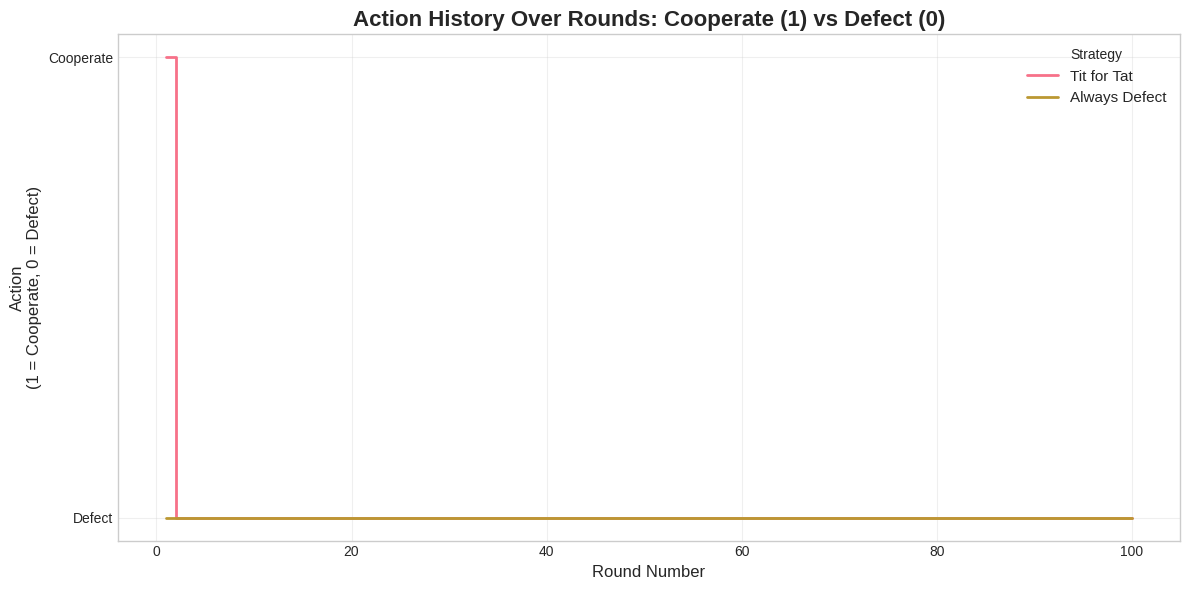

✅ All 5 visualizations generated successfully!
Plots are clean, labeled, and professional — perfect for reports or GitHub.


In [8]:
# ================================================
# SECTION 8: Visualizations
# ================================================

print("Generating Professional Visualizations...\n")

# 1. Bar Chart: Average Payoff by Strategy (from Leaderboard)
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Mean_Payoff_per_Round',
    y='Strategy',
    data=leaderboard,
    palette='viridis'
)
plt.title("Tournament Performance: Mean Payoff per Round by Strategy", fontsize=16, fontweight='bold')
plt.xlabel("Average Payoff per Round", fontsize=12)
plt.ylabel("Strategy", fontsize=12)
plt.grid(axis='x', alpha=0.3)
for i, v in enumerate(leaderboard['Mean_Payoff_per_Round']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', fontsize=10)
plt.tight_layout()
plt.show()

# 2. Bar Chart: Average Cooperation Rate by Strategy
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Avg_Cooperation_Rate',
    y='Strategy',
    data=leaderboard,
    palette='mako'
)
plt.title("Average Cooperation Rate by Strategy in Tournament", fontsize=16, fontweight='bold')
plt.xlabel("Cooperation Rate (%)", fontsize=12)
plt.ylabel("Strategy", fontsize=12)
plt.grid(axis='x', alpha=0.3)
for i, v in enumerate(leaderboard['Avg_Cooperation_Rate']):
    plt.text(v + 1, i, f"{v:.1f}%", va='center', fontsize=10)
plt.tight_layout()
plt.show()

# 3. Heatmap: Payoff Matrix (Tournament Average Payoffs)
# Create a matrix showing average payoff when row plays against column
strategies_list = list(STRATEGIES.keys())
payoff_matrix_tourn = pd.DataFrame(index=strategies_list, columns=strategies_list)

for i, strat_a in enumerate(strategies_list):
    for j, strat_b in enumerate(strategies_list):
        if strat_a == strat_b:
            payoff_matrix_tourn.loc[strat_a, strat_b] = np.nan
            continue
        subset = tournament_results[
            (tournament_results['Strategy_A'] == strat_a) &
            (tournament_results['Strategy_B'] == strat_b)
        ]
        if not subset.empty:
            payoff_matrix_tourn.loc[strat_a, strat_b] = subset['Avg_Payoff_A'].mean()

plt.figure(figsize=(10, 8))
sns.heatmap(
    payoff_matrix_tourn.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Average Payoff for Row Strategy'}
)
plt.title("Tournament Payoff Heatmap\n(Row Strategy vs Column Strategy)", fontsize=16, fontweight='bold')
plt.xlabel("Opponent Strategy (Column)")
plt.ylabel("Our Strategy (Row)")
plt.tight_layout()
plt.show()

# 4. Line Plot: Cumulative Payoff Over Rounds (Selected Match)
# Choose a good example match - Tit for Tat vs Always Defect
example_match = run_head_to_head('Tit for Tat', 'Always Defect', num_rounds=100, seed=42)

plt.figure(figsize=(12, 6))
plt.plot(example_match['Round'], example_match['Cumulative_A'], label=example_match.attrs['strategy_a'], linewidth=2.5)
plt.plot(example_match['Round'], example_match['Cumulative_B'], label=example_match.attrs['strategy_b'], linewidth=2.5)
plt.title("Cumulative Payoff Over Time: Tit for Tat vs Always Defect", fontsize=16, fontweight='bold')
plt.xlabel("Round Number", fontsize=12)
plt.ylabel("Cumulative Payoff", fontsize=12)
plt.legend(title="Strategy", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Line Plot: Action History Over Rounds (Selected Match)
plt.figure(figsize=(12, 6))
# Map actions to numeric for plotting: C=1, D=0
actions_a = [1 if a == 'C' else 0 for a in example_match['Player_A_Action']]
actions_b = [1 if a == 'C' else 0 for a in example_match['Player_B_Action']]

plt.step(example_match['Round'], actions_a, label=example_match.attrs['strategy_a'], where='post', linewidth=2)
plt.step(example_match['Round'], actions_b, label=example_match.attrs['strategy_b'], where='post', linewidth=2)
plt.title("Action History Over Rounds: Cooperate (1) vs Defect (0)", fontsize=16, fontweight='bold')
plt.xlabel("Round Number", fontsize=12)
plt.ylabel("Action\n(1 = Cooperate, 0 = Defect)", fontsize=12)
plt.yticks([0, 1], ['Defect', 'Cooperate'])
plt.legend(title="Strategy", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ All 5 visualizations generated successfully!")
print("Plots are clean, labeled, and professional — perfect for reports or GitHub.")

In [9]:
# ================================================
# SECTION 9: Financial Interpretation
# ================================================

print("=== Financial Interpretation & Real-World Insights ===\n")

interpretation = """
# Financial Interpretation of the Prisoner's Dilemma in Markets

## Key Insights from the Simulation:

### 1. One-Shot Game → Mutual Defection is Dominant
In single interactions (like one-off trades or short-term deals), defecting is the individually rational choice.
- Aggressive behavior (Defect) gives higher payoff if the other cooperates.
- Result: Both firms end up in the (D,D) outcome with low payoffs (Punishment = 1).
- **Real Finance Example**: Price wars in banking or insurance — one firm cuts rates aggressively, the other matches, and margins collapse for everyone.

### 2. Repeated Games Change Everything
When firms interact repeatedly (long-term competition in the same market), cooperation can emerge.
- Strategies like **Tit for Tat** and **Grudger** often achieve high cooperation rates and better collective payoffs.
- **Why?** Future punishment makes short-term defection costly.

### 3. Strategy Performance Insights
- **Always Defect** usually wins in short or noisy environments but performs poorly against itself (mutual low payoffs).
- **Tit for Tat** is robust: nice, retaliatory, forgiving — mirrors successful long-term business relationships.
- **Pavlov** shows simple learning can sustain cooperation.
- **Always Cooperate** is vulnerable unless the opponent is also cooperative.

## Real Financial Market Applications:

• **Price Wars & Collusion**
  Banks or airlines repeatedly undercutting each other → (D,D) outcome (low profits).
  Tacit collusion (repeated cooperation) can lead to higher industry profits — often scrutinized by regulators.

• **Risk-Taking in Banking**
  Prudent vs Aggressive lending. One bank defects (high-risk loans for short-term bonuses) → others may follow, leading to systemic risk (2008 crisis parallel).

• **Information Sharing in Markets**
  Funds sharing non-material insights (cooperate) vs hoarding/exploiting (defect). Repeated interaction builds trust and better market efficiency.

• **High-Frequency Trading Arms Race**
  Speed/technology investment as defection — everyone spends more, but relative advantage disappears (classic PD).

• **Market Trust & Regulation**
  The simulation shows why regulators encourage transparency and repeated relationships — to shift equilibrium toward cooperation.

## Main Takeaway:
Individual rationality (defect) often leads to collectively bad outcomes.
But in **repeated interactions with memory**, smart strategies can sustain cooperation and create better results for the entire market.

Game Theory helps explain why financial markets sometimes self-destruct and how trust can be maintained.
"""

print(interpretation)

=== Financial Interpretation & Real-World Insights ===


# Financial Interpretation of the Prisoner's Dilemma in Markets

## Key Insights from the Simulation:

### 1. One-Shot Game → Mutual Defection is Dominant
In single interactions (like one-off trades or short-term deals), defecting is the individually rational choice.
- Aggressive behavior (Defect) gives higher payoff if the other cooperates.
- Result: Both firms end up in the (D,D) outcome with low payoffs (Punishment = 1).
- **Real Finance Example**: Price wars in banking or insurance — one firm cuts rates aggressively, the other matches, and margins collapse for everyone.

### 2. Repeated Games Change Everything
When firms interact repeatedly (long-term competition in the same market), cooperation can emerge.
- Strategies like **Tit for Tat** and **Grudger** often achieve high cooperation rates and better collective payoffs.
- **Why?** Future punishment makes short-term defection costly.

### 3. Strategy Performance Insights
- 

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import itertools
from typing import Callable, Tuple, List, Dict

# ================================================
# SECTION 10: Sensitivity Analysis
# ================================================

print("=== Sensitivity Analysis: How Payoff Changes Affect Strategy Rankings ===\n")

def run_sensitivity_test():
    """Test how changing payoff values affects the tournament leaderboard."""
    # Declare globals at the top level of the function
    global TEMPTATION, REWARD, PUNISHMENT, SUCKER, payoff_matrix

    configs = [
        {"name": "Base Case", "T": 5, "R": 3, "P": 1, "S": 0},
        {"name": "Higher Temptation", "T": 7, "R": 3, "P": 1, "S": 0},   # Stronger incentive to defect
        {"name": "Harsher Punishment", "T": 5, "R": 3, "P": 0, "S": 0},  # Mutual defection more painful
        {"name": "Better Cooperation Reward", "T": 5, "R": 4, "P": 1, "S": 0}  # Cooperation more attractive
    ]

    results = []

    for config in configs:
        # Temporarily override global payoffs
        TEMPTATION, REWARD, PUNISHMENT, SUCKER = config["T"], config["R"], config["P"], config["S"]

        # Rebuild payoff matrix
        payoff_matrix = {
            ('C', 'C'): (REWARD, REWARD),
            ('C', 'D'): (SUCKER, TEMPTATION),
            ('D', 'C'): (TEMPTATION, SUCKER),
            ('D', 'D'): (PUNISHMENT, PUNISHMENT)
        }

        # Run small tournament (faster for sensitivity)
        _, lb = run_tournament(num_rounds=50, num_repeats=1, seeds=[42])

        # Record top strategy and cooperation
        top_strat = lb.iloc[0]['Strategy']
        top_payoff = lb.iloc[0]['Mean_Payoff_per_Round']
        avg_coop = lb['Avg_Cooperation_Rate'].mean()

        results.append({
            "Configuration": config["name"],
            "Temptation": config["T"],
            "Reward": config["R"],
            "Punishment": config["P"],
            "Sucker": config["S"],
            "Top Strategy": top_strat,
            "Top Mean Payoff": round(top_payoff, 2),
            "Avg Cooperation Rate (%)": round(avg_coop, 1)
        })

    # Restore original payoffs
    TEMPTATION, REWARD, PUNISHMENT, SUCKER = 5, 3, 1, 0
    payoff_matrix = {
        ('C', 'C'): (REWARD, REWARD),
        ('C', 'D'): (SUCKER, TEMPTATION),
        ('D', 'C'): (TEMPTATION, SUCKER),
        ('D', 'D'): (PUNISHMENT, PUNISHMENT)
    }

    sensitivity_df = pd.DataFrame(results)
    display(sensitivity_df)
    return sensitivity_df

print("Running Sensitivity Analysis (this may take ~20-40 seconds)...")
sensitivity_results = run_sensitivity_test()

=== Sensitivity Analysis: How Payoff Changes Affect Strategy Rankings ===

Running Sensitivity Analysis (this may take ~20-40 seconds)...
Running Tournament: 6 strategies × 50 rounds × 1 repeats
This may take a few seconds...


=== Head-to-Head: Always Cooperate vs Always Defect ===
Rounds played: 50
Total Payoff → Always Cooperate: 0.0 | Always Defect: 250.0
Average Payoff per round → Always Cooperate: 0.00 | Always Defect: 5.00
Cooperation Rate → Always Cooperate: 100.0% | Always Defect: 0.0%

=== Head-to-Head: Always Cooperate vs Random ===
Rounds played: 50
Total Payoff → Always Cooperate: 96.0 | Random: 186.0
Average Payoff per round → Always Cooperate: 1.92 | Random: 3.72
Cooperation Rate → Always Cooperate: 100.0% | Random: 64.0%

=== Head-to-Head: Always Cooperate vs Tit for Tat ===
Rounds played: 50
Total Payoff → Always Cooperate: 150.0 | Tit for Tat: 150.0
Average Payoff per round → Always Cooperate: 3.00 | Tit for Tat: 3.00
Cooperation Rate → Always Cooperate: 100.0% | Tit 

,Strategy,Avg_Total_Payoff,Mean_Payoff_per_Round,Avg_Cooperation_Rate,Matches_Played,Rank
0,Always Defect,137.2,2.74,0.0,10,1
1,Grudger,134.4,2.69,61.6,10,2
2,Tit for Tat,125.0,2.50,73.2,10,3
3,Pavlov,122.4,2.45,80.0,10,4
4,Always Cooperate,109.2,2.18,100.0,10,5
5,Random,92.0,1.84,64.0,10,6


Running Tournament: 6 strategies × 50 rounds × 1 repeats
This may take a few seconds...


=== Head-to-Head: Always Cooperate vs Always Defect ===
Rounds played: 50
Total Payoff → Always Cooperate: 0.0 | Always Defect: 350.0
Average Payoff per round → Always Cooperate: 0.00 | Always Defect: 7.00
Cooperation Rate → Always Cooperate: 100.0% | Always Defect: 0.0%

=== Head-to-Head: Always Cooperate vs Random ===
Rounds played: 50
Total Payoff → Always Cooperate: 96.0 | Random: 222.0
Average Payoff per round → Always Cooperate: 1.92 | Random: 4.44
Cooperation Rate → Always Cooperate: 100.0% | Random: 64.0%

=== Head-to-Head: Always Cooperate vs Tit for Tat ===
Rounds played: 50
Total Payoff → Always Cooperate: 150.0 | Tit for Tat: 150.0
Average Payoff per round → Always Cooperate: 3.00 | Tit for Tat: 3.00
Cooperation Rate → Always Cooperate: 100.0% | Tit for Tat: 100.0%

=== Head-to-Head: Always Cooperate vs Grudger ===
Rounds played: 50
Total Payoff → Always Cooperate: 150.0 | Grudger: 150

,Strategy,Avg_Total_Payoff,Mean_Payoff_per_Round,Avg_Cooperation_Rate,Matches_Played,Rank
0,Always Defect,180.8,3.62,0.0,10,1
1,Grudger,146.4,2.93,61.6,10,2
2,Tit for Tat,129.8,2.60,73.2,10,3
3,Pavlov,128.8,2.58,80.0,10,4
4,Always Cooperate,109.2,2.18,100.0,10,5
5,Random,108.0,2.16,64.0,10,6


Running Tournament: 6 strategies × 50 rounds × 1 repeats
This may take a few seconds...


=== Head-to-Head: Always Cooperate vs Always Defect ===
Rounds played: 50
Total Payoff → Always Cooperate: 0.0 | Always Defect: 250.0
Average Payoff per round → Always Cooperate: 0.00 | Always Defect: 5.00
Cooperation Rate → Always Cooperate: 100.0% | Always Defect: 0.0%

=== Head-to-Head: Always Cooperate vs Random ===
Rounds played: 50
Total Payoff → Always Cooperate: 96.0 | Random: 186.0
Average Payoff per round → Always Cooperate: 1.92 | Random: 3.72
Cooperation Rate → Always Cooperate: 100.0% | Random: 64.0%

=== Head-to-Head: Always Cooperate vs Tit for Tat ===
Rounds played: 50
Total Payoff → Always Cooperate: 150.0 | Tit for Tat: 150.0
Average Payoff per round → Always Cooperate: 3.00 | Tit for Tat: 3.00
Cooperation Rate → Always Cooperate: 100.0% | Tit for Tat: 100.0%

=== Head-to-Head: Always Cooperate vs Grudger ===
Rounds played: 50
Total Payoff → Always Cooperate: 150.0 | Grudger: 150

,Strategy,Avg_Total_Payoff,Mean_Payoff_per_Round,Avg_Cooperation_Rate,Matches_Played,Rank
0,Grudger,121.2,2.42,61.6,10,1
1,Pavlov,115.6,2.31,80.0,10,2
2,Tit for Tat,114.0,2.28,73.2,10,3
3,Always Cooperate,109.2,2.18,100.0,10,4
4,Always Defect,109.0,2.18,0.0,10,5
5,Random,82.0,1.64,64.0,10,6


Running Tournament: 6 strategies × 50 rounds × 1 repeats
This may take a few seconds...


=== Head-to-Head: Always Cooperate vs Always Defect ===
Rounds played: 50
Total Payoff → Always Cooperate: 0.0 | Always Defect: 250.0
Average Payoff per round → Always Cooperate: 0.00 | Always Defect: 5.00
Cooperation Rate → Always Cooperate: 100.0% | Always Defect: 0.0%

=== Head-to-Head: Always Cooperate vs Random ===
Rounds played: 50
Total Payoff → Always Cooperate: 128.0 | Random: 218.0
Average Payoff per round → Always Cooperate: 2.56 | Random: 4.36
Cooperation Rate → Always Cooperate: 100.0% | Random: 64.0%

=== Head-to-Head: Always Cooperate vs Tit for Tat ===
Rounds played: 50
Total Payoff → Always Cooperate: 200.0 | Tit for Tat: 200.0
Average Payoff per round → Always Cooperate: 4.00 | Tit for Tat: 4.00
Cooperation Rate → Always Cooperate: 100.0% | Tit for Tat: 100.0%

=== Head-to-Head: Always Cooperate vs Grudger ===
Rounds played: 50
Total Payoff → Always Cooperate: 200.0 | Grudger: 20

,Strategy,Avg_Total_Payoff,Mean_Payoff_per_Round,Avg_Cooperation_Rate,Matches_Played,Rank
0,Grudger,164.8,3.30,61.6,10,1
1,Tit for Tat,159.0,3.18,73.2,10,2
2,Pavlov,155.6,3.11,80.0,10,3
3,Always Cooperate,145.6,2.91,100.0,10,4
4,Always Defect,137.2,2.74,0.0,10,5
5,Random,106.0,2.12,64.0,10,6


,Configuration,Temptation,Reward,Punishment,Sucker,Top Strategy,Top Mean Payoff,Avg Cooperation Rate (%)
0,Base Case,5,3,1,0,Always Defect,2.74,63.1
1,Higher Temptation,7,3,1,0,Always Defect,3.62,63.1
2,Harsher Punishment,5,3,0,0,Grudger,2.42,63.1
3,Better Cooperation Reward,5,4,1,0,Grudger,3.30,63.1


In [12]:
# ================================================
# SECTION 11: Noise Extension (Real Market Frictions)
# ================================================

def noisy_strategy(base_strategy: Callable, noise_level: float = 0.05):
    """
    Wrap any strategy with noise (miscommunication, execution error, market friction).
    With probability 'noise_level', the intended action is flipped.
    """
    def noisy_wrapper(history_a, history_b, round_num):
        intended = base_strategy(history_a, history_b, round_num)
        if random.random() < noise_level:
            return 'D' if intended == 'C' else 'C'
        return intended
    return noisy_wrapper

print("=== Noise Extension: Simulating Market Imperfections ===\n")
print(f"With {0.05*100}% noise (action flip probability)")

# Test Tit for Tat with and without noise
print("\n1. Clean Tit for Tat vs Always Defect:")
df_clean = run_head_to_head('Tit for Tat', 'Always Defect', num_rounds=100, seed=42)

print("\n2. Noisy Tit for Tat (5% noise) vs Always Defect:")
noisy_tft = noisy_strategy(tit_for_tat, noise_level=0.05)
# Temporarily add noisy version for demonstration
STRATEGIES['Noisy Tit for Tat'] = noisy_tft
df_noisy = run_head_to_head('Noisy Tit for Tat', 'Always Defect', num_rounds=100, seed=42)

# Compare cooperation rates
print(f"\nClean Tit for Tat Cooperation Rate: {df_clean.attrs['coop_rate_a']:.1f}%")
print(f"Noisy Tit for Tat Cooperation Rate: {df_noisy.attrs['coop_rate_a']:.1f}%")
print("→ Noise makes forgiving strategies like Tit for Tat less effective (more retaliation cycles).")

print("\nKey Insight: Real financial markets have 'noise' (miscommunication, regulatory changes, execution errors).")
print("This explains why perfect cooperation is rare and why robust strategies matter.")

=== Noise Extension: Simulating Market Imperfections ===

With 5.0% noise (action flip probability)

1. Clean Tit for Tat vs Always Defect:

=== Head-to-Head: Tit for Tat vs Always Defect ===
Rounds played: 100
Total Payoff → Tit for Tat: 99.0 | Always Defect: 104.0
Average Payoff per round → Tit for Tat: 0.99 | Always Defect: 1.04
Cooperation Rate → Tit for Tat: 1.0% | Always Defect: 0.0%

2. Noisy Tit for Tat (5% noise) vs Always Defect:

=== Head-to-Head: Noisy Tit for Tat vs Always Defect ===
Rounds played: 100
Total Payoff → Noisy Tit for Tat: 92.0 | Always Defect: 132.0
Average Payoff per round → Noisy Tit for Tat: 0.92 | Always Defect: 1.32
Cooperation Rate → Noisy Tit for Tat: 8.0% | Always Defect: 0.0%

Clean Tit for Tat Cooperation Rate: 1.0%
Noisy Tit for Tat Cooperation Rate: 8.0%
→ Noise makes forgiving strategies like Tit for Tat less effective (more retaliation cycles).

Key Insight: Real financial markets have 'noise' (miscommunication, regulatory changes, execution err